# Question Answering Success Analysis

In this notebook the the performance of the boardgame rulebook question answering system will be analyzed. It loads question-answer results, computes success metrics, and visualizes the results with graphs.

In [16]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

%matplotlib inline

## Load Question Answering Results Data

Load the results data (CSV or JSON) containing ground truth answers and predicted answers. Update the file path as needed.

In [17]:
# Example: Load results from a CSV or JSON file
# Update the file path as needed
results_path = '../data/processed/qa_results.csv'  # or .json

# Try loading CSV, fallback to JSON
try:
    df = pd.read_csv(results_path)
except Exception:
    df = pd.read_json(results_path)

df.head()

,question,ground_truth,predicted,score,page,section,chunk_index,best_chunk_rank
0,When do I increase my radiation?,Each time a Stalker slides their Turn token (a...,Radiation During Movement of Movement caused y...,0.715884,13,POST MISSION CLEANUP,NaN,4.0
1,How do I win the mission?,Each Mission has a main Objective card which s...,Each Mission is played through several game Ro...,0.432099,18,GAME ROUND STRUCTURE,NaN,17.0
2,How many players can play this game?,This game can be played by 1-4 players.,Fully Occupied Space A space with a number of ...,0.231481,12,POST MISSION CLEANUP,NaN,10.0
3,How does movement work?,"On your turn, when you use the Move action, yo...",There are two types of Movement that Enemies p...,0.333333,32,ENEMY MOVEMENT RULES,NaN,NaN
4,How do I perform an attack action?,Choose an Attack Action and a valid Target. - ...,To perform an Attack follow these steps: 1. Ch...,1.000000,44,STALKER ATTACK SEQUENCE,NaN,2.0


## Preprocess and Explore Data

Clean and preprocess the data, handle missing values, and display basic statistics about the dataset.

In [18]:
# Drop rows with missing values in essential columns only
clean_df = df.dropna(subset=['question', 'ground_truth', 'predicted'])

# Show basic statistics
print('Number of questions:', len(clean_df))
print('Columns:', clean_df.columns.tolist())
clean_df.describe(include='all')

Number of questions: 39
Columns: ['question', 'ground_truth', 'predicted', 'score', 'page', 'section', 'chunk_index', 'best_chunk_rank']


,question,ground_truth,predicted,score,page,section,chunk_index,best_chunk_rank
count,39,39,39,39.000000,39.000000,39,0.0,15.000000
unique,39,38,35,NaN,NaN,7,NaN,NaN
top,When do I increase my radiation?,"When any Stalker dies, you fail your current M...",4. Target a Body Part: - the Attack allows you...,NaN,NaN,GAME ROUND STRUCTURE,NaN,NaN
freq,1,2,3,NaN,NaN,10,NaN,NaN
mean,NaN,NaN,NaN,0.426280,25.564103,NaN,NaN,8.266667
std,NaN,NaN,NaN,0.235905,9.925498,NaN,NaN,7.045431
min,NaN,NaN,NaN,0.023704,11.000000,NaN,NaN,1.000000
25%,NaN,NaN,NaN,0.309962,18.000000,NaN,NaN,1.500000
50%,NaN,NaN,NaN,0.400000,22.000000,NaN,NaN,5.000000
75%,NaN,NaN,NaN,0.478865,32.000000,NaN,NaN,15.500000


## Calculate Success Metrics Using Similarity

Compute and visualize fuzzy string similarity (token set ratio) for the question answering results. This provides a more realistic measure of model performance for free-form answers.

Using pre-computed similarity scores from CSV
Mean similarity: 42.63
Questions passing threshold: 4/39


C:\Users\I544554\AppData\Local\Temp\ipykernel_17568\2540375577.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['similarity'] = clean_df['score'] * 100
C:\Users\I544554\AppData\Local\Temp\ipykernel_17568\2540375577.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['correct'] = clean_df['similarity'] >= threshold


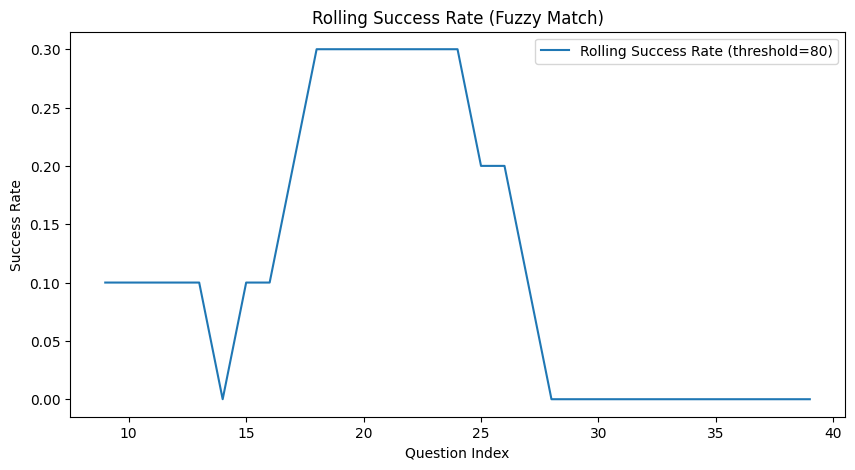

In [19]:
# Define threshold for fuzzy match success
threshold = 80

# Use pre-computed similarity scores from CSV's 'score' column (0-1 normalized)
# Convert to 0-100 scale to match token_set_ratio convention
if 'score' in clean_df.columns and 'similarity' not in clean_df.columns:
    clean_df['similarity'] = clean_df['score'] * 100
    print('Using pre-computed similarity scores from CSV')
elif 'similarity' not in clean_df.columns:
    # Fallback: compute if not present
    try:
        from rapidfuzz import fuzz
    except ImportError:
        import sys, subprocess
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'rapidfuzz'])
        from rapidfuzz import fuzz
    similarities = [fuzz.token_set_ratio(str(gt), str(pred)) for gt, pred in zip(clean_df['ground_truth'], clean_df['predicted'])]
    clean_df['similarity'] = similarities
    print('Computed similarity scores using rapidfuzz')

clean_df['correct'] = clean_df['similarity'] >= threshold

print(f'Mean similarity: {clean_df["similarity"].mean():.2f}')
print(f'Questions passing threshold: {clean_df["correct"].sum()}/{len(clean_df)}')

# Rolling success rate
window = 10
rolling_success = clean_df['correct'].rolling(window).mean()
plt.figure(figsize=(10,5))
plt.plot(rolling_success, label=f'Rolling Success Rate (threshold={threshold})')
plt.xlabel('Question Index')
plt.ylabel('Success Rate')
plt.title('Rolling Success Rate (Fuzzy Match)')
plt.legend()
plt.show()

## Fuzzy String Similarity Analysis

Since exact string match metrics are too strict for free-form answers, we use fuzzy string similarity to better gauge answer quality.

Mean similarity: 42.63


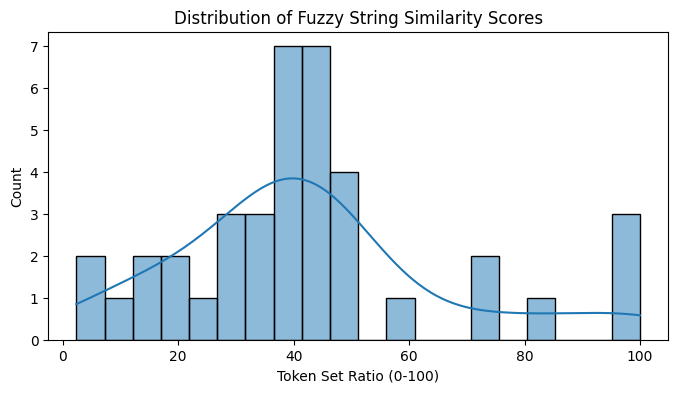

In [20]:
# Use the similarity scores already computed in the previous cell
similarities = clean_df['similarity'].tolist()

print(f'Mean similarity: {np.mean(similarities):.2f}')
plt.figure(figsize=(8,4))
sns.histplot(similarities, bins=20, kde=True)
plt.title('Distribution of Fuzzy String Similarity Scores')
plt.xlabel('Token Set Ratio (0-100)')
plt.ylabel('Count')
plt.show()

## Fuzzy Match Confusion Matrix

We treat predictions as correct if their similarity is above the threshold, and plot a confusion matrix.

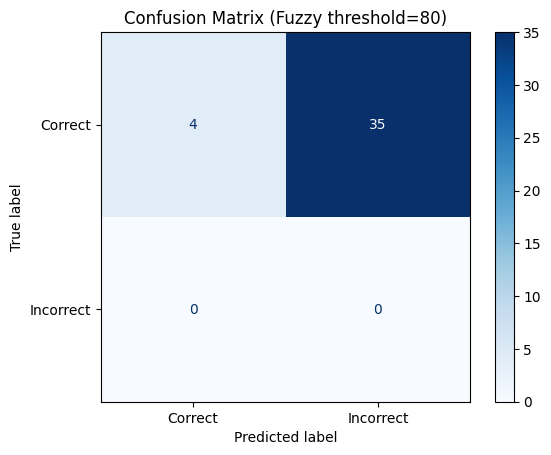

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# True: all answers are expected to be correct (since each row is a QA pair)
y_true_bin = np.ones(len(clean_df), dtype=int)
y_pred_bin = clean_df['correct'].astype(int)

cm = confusion_matrix(y_true_bin, y_pred_bin, labels=[1,0])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Correct', 'Incorrect'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix (Fuzzy threshold={threshold})')
plt.show()

## Visualize Success Rate Over Time (Fuzzy Match)

We define a prediction as 'correct' if its similarity to the ground truth is above a threshold (e.g., 80).

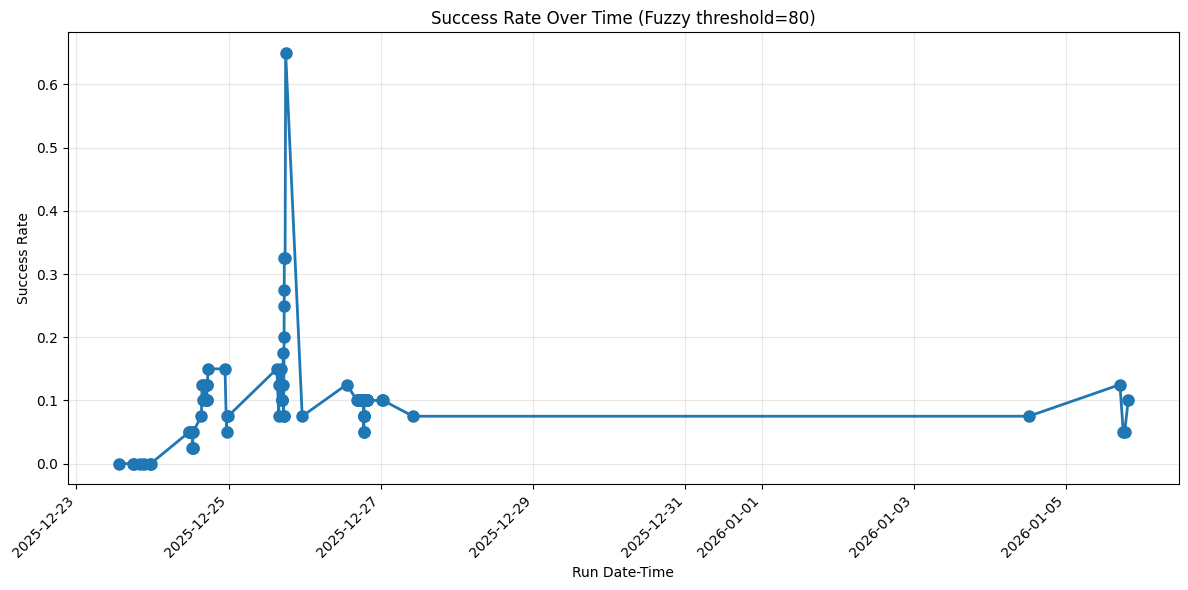

Analyzed 91 QA result files from 2025-12-23 13:17:38 to 2026-01-05 19:32:45


In [22]:
import glob
import re
from datetime import datetime

# Find all archived qa_results files
archive_files = sorted(glob.glob('../data/processed/archive/qa_results_*.csv'))

# Extract datetime from filename for sorting
pattern = re.compile(r'qa_results_(\d{4})-(\d{2})-(\d{2})_(\d{2})-(\d{2})-(\d{2})_\d+s(?:_w\d+)?\.csv$')

def extract_dt(fname):
    match = pattern.search(fname)
    if match:
        year, month, day, hour, minute, second = match.groups()
        return datetime(int(year), int(month), int(day), int(hour), int(minute), int(second))
    return None

# Filter and sort files by datetime
archive_data = [(f, extract_dt(f)) for f in archive_files]
archive_data = [(f, dt) for f, dt in archive_data if dt is not None]
archive_data.sort(key=lambda x: x[1])

success_rates = []
datetimes = []
threshold = 80

for f, dt in archive_data:
    df = pd.read_csv(f)
    if 'similarity' not in df.columns:
        # Compute similarity if not present
        try:
            from rapidfuzz import fuzz
        except ImportError:
            import sys, subprocess
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'rapidfuzz'])
            from rapidfuzz import fuzz
        similarities = [fuzz.token_set_ratio(str(gt), str(pred)) for gt, pred in zip(df['ground_truth'], df['predicted'])]
        df['similarity'] = similarities
    correct = (df['similarity'] >= threshold).mean()
    success_rates.append(correct)
    datetimes.append(dt)

plt.figure(figsize=(12,6))
plt.plot(datetimes, success_rates, marker='o', linestyle='-', linewidth=2, markersize=8)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Run Date-Time')
plt.ylabel('Success Rate')
plt.title(f'Success Rate Over Time (Fuzzy threshold={threshold})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Analyzed {len(datetimes)} QA result files from {datetimes[0].strftime('%Y-%m-%d %H:%M:%S')} to {datetimes[-1].strftime('%Y-%m-%d %H:%M:%S')}")

## Compare Different Hybrid Search Weights

Compare the performance of different vector vs keyword weight configurations to find the optimal balance.

File not found: ../../data/processed/qa_results_2026-01-05_19-40-53_19s-20.csv
File not found: ../../data/processed/qa_results_2026-01-05_19-42-13_19s-30.csv
File not found: ../../data/processed/qa_results_2026-01-05_19-42-51_18s-40.csv
File not found: ../../data/processed/qa_results_2026-01-05_19-43-26_18s-50.csv
File not found: ../../data/processed/qa_results_2026-01-05_19-50-07_19s-60.csv
File not found: ../../data/processed/qa_results_2026-01-05_19-44-54_18s-70.csv
File not found: ../../data/processed/qa_results_2026-01-05_19-45-28_18s-80.csv
File not found: ../../data/processed/qa_results_2026-01-05_18-26-54_21s.csv
File not found: ../../data/processed/qa_results_2026-01-05_19-46-03_19s-90.csv

HYBRID SEARCH WEIGHT COMPARISON
Empty DataFrame
Columns: []
Index: []


KeyError: 'Mean Similarity'

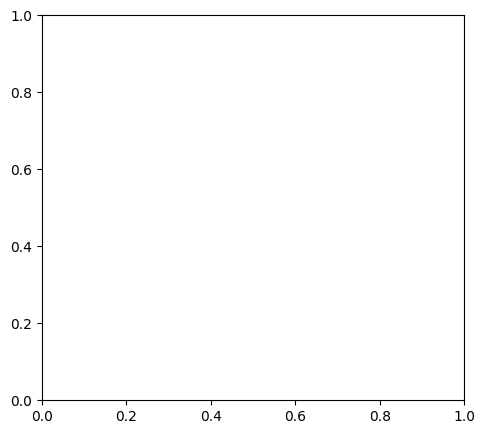

In [ ]:
import glob
import pandas as pd
from rapidfuzz import fuzz
import numpy as np

# Find weight test files
weight_files = {
    'w20 (20% vector, 80% keyword)': '../data/processed/archive/qa_results_2026-01-05_19-40-53_19s-20.csv',
    'w30 (30% vector, 70% keyword)': '../data/processed/archive/qa_results_2026-01-05_19-42-13_19s-30.csv',
    'w40 (40% vector, 60% keyword)': '../data/processed/archive/qa_results_2026-01-05_19-42-51_18s-40.csv',
    'w50 (50% vector, 50% keyword)': '../data/processed/archive/qa_results_2026-01-05_19-43-26_18s-50.csv',
    'w60 (60% vector, 40% keyword)': '../data/processed/archive/qa_results_2026-01-05_19-50-07_19s-60.csv',
    'w70 (70% vector, 30% keyword)': '../data/processed/archive/qa_results_2026-01-05_19-44-54_18s-70.csv',
    'w80 (80% vector, 20% keyword)': '../data/processed/archive/qa_results_2026-01-05_19-45-28_18s-80.csv',
    'w85 (85% vector, 15% keyword)': '../data/processed/archive/qa_results_2026-01-05_18-26-54_21s.csv',
    'w90 (90% vector, 10% keyword)': '../data/processed/archive/qa_results_2026-01-05_19-46-03_19s-90.csv',
}

threshold = 80
comparison_results = []

for weight_label, filepath in weight_files.items():
    try:
        df = pd.read_csv(filepath)
        
        # Calculate similarities if not present
        if 'similarity' not in df.columns:
            similarities = [fuzz.token_set_ratio(str(gt), str(pred)) 
                          for gt, pred in zip(df['ground_truth'], df['predicted'])]
            df['similarity'] = similarities
        
        # Calculate metrics
        mean_sim = df['similarity'].mean()
        success_rate = (df['similarity'] >= threshold).mean()
        
        comparison_results.append({
            'Weight Config': weight_label,
            'Mean Similarity': mean_sim,
            'Success Rate': success_rate,
            'Success Count': (df['similarity'] >= threshold).sum(),
            'Total': len(df)
        })
    except FileNotFoundError:
        print(f"File not found: {filepath}")

# Create comparison dataframe
comparison_df = pd.DataFrame(comparison_results)
print("\n" + "="*70)
print("HYBRID SEARCH WEIGHT COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(len(comparison_df)), comparison_df['Mean Similarity'], color='steelblue')
plt.xticks(range(len(comparison_df)), comparison_df['Weight Config'], rotation=15, ha='right')
plt.ylabel('Mean Similarity Score')
plt.title('Mean Similarity by Weight Configuration')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(range(len(comparison_df)), comparison_df['Success Rate'] * 100, color='coral')
plt.xticks(range(len(comparison_df)), comparison_df['Weight Config'], rotation=15, ha='right')
plt.ylabel('Success Rate (%)')
plt.title(f'Success Rate by Weight (threshold={threshold})')
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()